In [50]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors

In [51]:
edges_df = pd.read_csv("enron_weighted_edges.csv")
# remove self-loops
edges_df = edges_df[edges_df['Source'] != edges_df['Target']]

# Get the full network
G_full = (nx.from_pandas_edgelist
    (edges_df,
    source='Source',
    target='Target',
    edge_attr='Weight',
    create_using=nx.DiGraph()))
print(f"Enron dataset: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

Enron dataset: 56595 nodes, 226837 edges


In [52]:
# get subgraph of active user with degree >= 10
nodes_to_keep = [node for node, degree in G_full.degree() if degree >= 10]
G = G_full.subgraph(nodes_to_keep).copy()

print(f"Filtered Graph (Degree >= 10): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Filtered Graph (Degree >= 10): 6347 nodes, 140501 edges


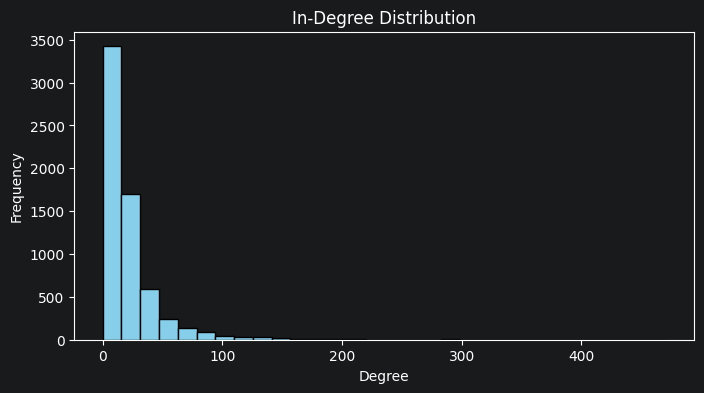

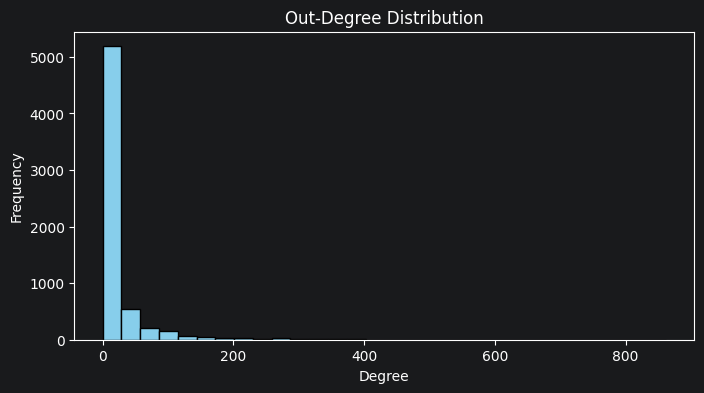

In [53]:
# In-degree and Out-degree distributions
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

def plot_dist(data, title):
    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=30, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.show()

plot_dist(in_degrees, "In-Degree Distribution")
plot_dist(out_degrees, "Out-Degree Distribution")

In [54]:
# Calculate Weighted Degree for all nodes
weighted_degrees = dict(G.degree(weight='weight'))

# To get the Top 10 by Weighted Degree:
top_10_weighted = sorted(weighted_degrees.items(), key=lambda x: x[1], reverse=True)[:10]

In [55]:
# Average Clustering Coefficient
avg_clustering = nx.average_clustering(G)
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

Average Clustering Coefficient: 0.2863


In [56]:
# Betweenness Centrality
betweenness = nx.betweenness_centrality(G, weight='Weight')
# Closeness Centrality
closeness = nx.closeness_centrality(G)

In [57]:
# Results
stats_df = pd.DataFrame({
    'Node_ID': list(betweenness.keys()),
    'Betweenness': list(betweenness.values()),
    'Closeness': list(closeness.values()),
    'In_Degree': [G.in_degree(n) for n in G.nodes()],
    'Out_Degree': [G.out_degree(n) for n in G.nodes()]
})

print("Top Influential Nodes by Betweenness:")
top = stats_df.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print(top)

Top Influential Nodes by Betweenness:
   Node_ID  Betweenness  Closeness  In_Degree  Out_Degree
0      585     0.057195   0.279259        457         664
1     1219     0.036690   0.285465        301         862
2     3266     0.025573   0.287169        339         781
3     4377     0.023264   0.293793        471         541
4      998     0.023006   0.297338        298         373
5     4404     0.020328   0.284688        439         445
6     3171     0.018965   0.271603        210         210
7     3207     0.017453   0.293708        417         411
8     4390     0.016727   0.282460        370         345
9      609     0.016051   0.293964        310         241


In [58]:
mapping_df = pd.read_csv("id_mapping.csv")
full_stats_with_names = stats_df.merge(mapping_df, left_on='Node_ID', right_on='ID')
full_stats_with_names = full_stats_with_names.drop(columns=['ID'])
top_10_labeled = full_stats_with_names.sort_values(by='Betweenness', ascending=False).head(10).reset_index(drop=True)
print("--- Top 10 Enron Nodes by Betweenness ---")
print(top_10_labeled[['Email_Address', 'Node_ID', 'Betweenness', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Betweenness ---
               Email_Address  Node_ID  Betweenness  In_Degree  Out_Degree
0    jeff.dasovich@enron.com      585     0.057195        457         664
1       sally.beck@enron.com     1219     0.036690        301         862
2      kenneth.lay@enron.com     3266     0.025573        339         781
3       tana.jones@enron.com     4377     0.023264        471         541
4    john.lavorato@enron.com      998     0.023006        298         373
5  sara.shackleton@enron.com     4404     0.020328        439         445
6    jeff.skilling@enron.com     3171     0.018965        210         210
7      mark.taylor@enron.com     3207     0.017453        417         411
8     gerald.nemec@enron.com     4390     0.016727        370         345
9  elizabeth.sager@enron.com      609     0.016051        310         241


In [59]:
full_stats_with_names['Total_Degree'] = full_stats_with_names['In_Degree'] + full_stats_with_names['Out_Degree']
top_10_total_degree = full_stats_with_names.sort_values(by='Total_Degree', ascending=False).head(10).reset_index(
    drop=True)

print("--- Top 10 Enron Nodes by Total Degree ---")
print(top_10_total_degree[['Node_ID', 'Email_Address', 'Total_Degree', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Total Degree ---
   Node_ID               Email_Address  Total_Degree  In_Degree  Out_Degree
0     1219        sally.beck@enron.com          1163        301         862
1      585     jeff.dasovich@enron.com          1121        457         664
2     3266       kenneth.lay@enron.com          1120        339         781
3     4377        tana.jones@enron.com          1012        471         541
4      886     david.forster@enron.com          1006        159         847
5     4404   sara.shackleton@enron.com           884        439         445
6     3207       mark.taylor@enron.com           828        417         411
7     1700  technology.enron@enron.com           793          0         793
8     3631      outlook.team@enron.com           731         38         693
9     4390      gerald.nemec@enron.com           715        370         345


In [60]:
# Top 10 by Closeness Centrality
top_10_closeness = (
full_stats_with_names.sort_values(by='Closeness', ascending=False).head(10).reset_index(drop=True))

print("--- Top 10 Enron Nodes by Closeness ---")
print(top_10_closeness[['Email_Address', 'Node_ID', 'Closeness', 'In_Degree', 'Out_Degree']])

--- Top 10 Enron Nodes by Closeness ---
               Email_Address  Node_ID  Closeness  In_Degree  Out_Degree
0   louise.kitchen@enron.com     1070   0.299039        291         413
1    john.lavorato@enron.com      998   0.297338        298         373
2  elizabeth.sager@enron.com      609   0.293964        310         241
3       tana.jones@enron.com     4377   0.293793        471         541
4      mark.taylor@enron.com     3207   0.293708        417         411
5       tim.belden@enron.com      521   0.292123        239         163
6     greg.whalley@enron.com      925   0.289666        329          83
7   barry.tycholiz@enron.com     1406   0.288234        181         121
8      kenneth.lay@enron.com     3266   0.287169        339         781
9    mark.haedicke@enron.com     1393   0.286897        251         296


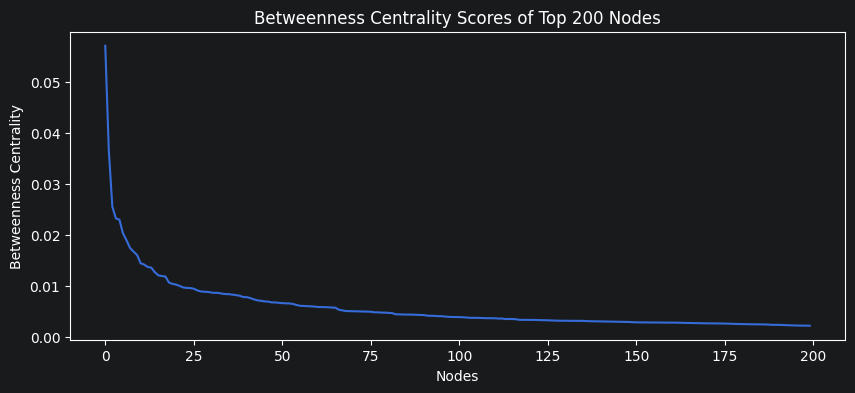

In [73]:
all_scores = sorted(stats_df['Betweenness'], reverse=True)
plt.figure(figsize=(10, 4))
plt.plot(all_scores[:200])
plt.title("Betweenness Centrality Scores of Top 200 Nodes")
plt.xlabel("Nodes")
plt.ylabel("Betweenness Centrality")
plt.show()

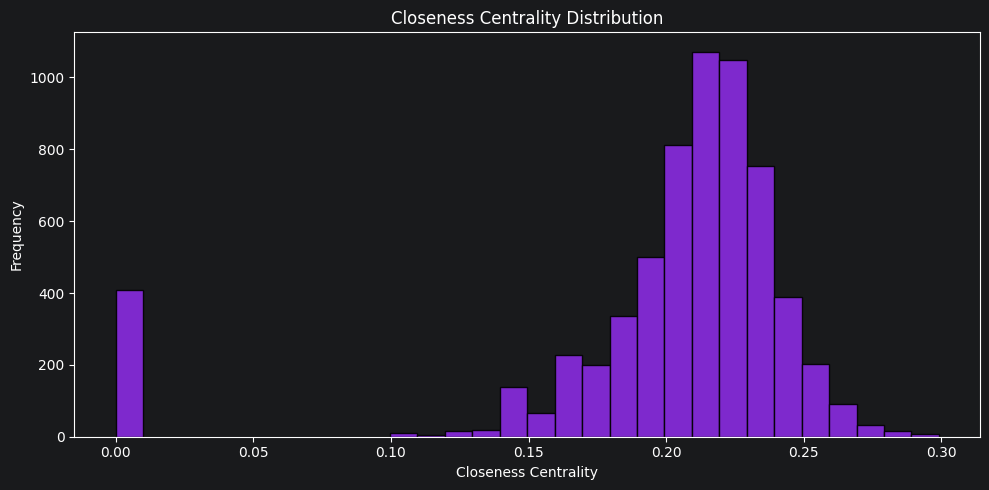

In [71]:
plt.figure(figsize=(10, 5))
plt.hist(stats_df['Closeness'], bins=30, color='blueviolet', edgecolor='black', alpha=0.9)
plt.title("Closeness Centrality Distribution")
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

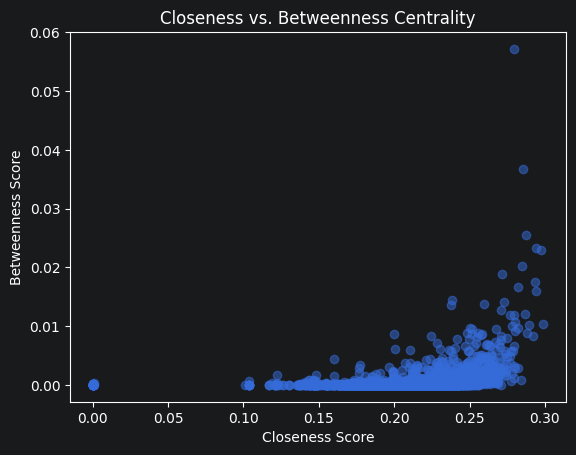

In [68]:
plt.scatter(stats_df['Closeness'], stats_df['Betweenness'], alpha=0.5)
plt.title("Closeness vs. Betweenness Centrality")
plt.xlabel("Closeness Score")
plt.ylabel("Betweenness Score")
plt.show()

In [76]:
# Convert to undirected to see if it matches Gephi
G_undirected = G.to_undirected()
print("Undirected Clustering:", nx.average_clustering(G_undirected))

Undirected Clustering: 0.38869697933505687
